In [5]:
import os, sys
from pathlib import Path

REPO_URL  = 'https://github.com/Daniel-Chacha/covid-xray-detection.git'
REPO_ROOT = Path('/kaggle/working/covid-xray-detection')
# DATA_ROOT = Path('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset')
CKPT_ROOT = Path('/kaggle/working/checkpoints')
CACHE_DIR = Path('/kaggle/tmp')          # ~60 GB scratch, not persisted

# Located by structure, not by name. Kaggle nests the mount under
# /kaggle/input/datasets/<owner>/<slug>/, and the inner folder name has changed
# across dataset versions — so find whatever directory contains COVID/images/,
# which is exactly the layout scan_dataset expects.
_found = sorted(Path('/kaggle/input').glob('**/COVID/images'))
assert _found, 'dataset not attached — use "+ Add Input", search covid19-radiography-database'
DATA_ROOT = _found[0].parent.parent



!pip install -q ImageHash
if (REPO_ROOT / '.git').exists():
    !git -C {REPO_ROOT} pull -q
else:
    !git clone -q {REPO_URL} {REPO_ROOT}

sys.path.insert(0, str(REPO_ROOT / 'src'))
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# No %load_ext autoreload: Kaggle's IPython imports `imp` inside that
# extension, and `imp` was removed in Python 3.12, so the magic raises. It is
# not needed here — code arrives by git clone, so a fresh session is current.
# After a mid-session `git pull`, reload explicitly:
#     import importlib, covid_xray.data; importlib.reload(covid_xray.data)
# or restart the kernel.

# Print the commit being run. A stale clone is the standard failure of this
# workflow — edit locally, forget to push, silently run yesterday's code.
!git -C {REPO_ROOT} log -1 --format='running commit %h  %s  (%cr)'
# assert DATA_ROOT.exists(), 'dataset not attached — use "+ Add Input"'
print('DATA_ROOT:', DATA_ROOT)


running commit d984b5f  feat: DenseNet121 builder with frozen BatchNorm, 8x8 probe, two-stage training loop  (19 hours ago)
DATA_ROOT: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset


In [4]:
# !ls -la /kaggle/input
!ls -la /kaggle/input/datasets
print('---')
_found = sorted(Path('/kaggle/input').glob('**/COVID/images'))
assert _found, 'no COVID/images found under /kaggle/input'
DATA_ROOT = _found[0].parent.parent
print('DATA_ROOT:', DATA_ROOT)
print(sorted(p.name for p in DATA_ROOT.iterdir()))


total 12
drwxr-xr-x 3 root root 4096 Jul 31 07:34 .
drwxr-xr-x 3 root root 4096 Jul 31 07:34 ..
drwxr-xr-x 3 root root 4096 Jul 31 07:34 tawsifurrahman
---
DATA_ROOT: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
['COVID', 'COVID.metadata.xlsx', 'Lung_Opacity', 'Lung_Opacity.metadata.xlsx', 'Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Viral Pneumonia', 'Viral Pneumonia.metadata.xlsx']


In [6]:
# 2. Confirm the GPU

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
!nvidia-smi --query-gpu=name,memory.total --format=csv


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [12]:
# 3. Manifests and run the helper

from covid_xray.config import load_config
from covid_xray.splits import load_manifest
from covid_xray.data import build_dataset
from covid_xray.augment import build_augmenter
from covid_xray.train import train_two_stage, enable_mixed_precision

manifests = {s: load_manifest(REPO_ROOT / 'data' / 'splits' / f'{s}.csv')
             for s in ('train', 'val', 'test')}
print({s: len(d) for s, d in manifests.items()})   # expect 14659 / 3141 / 3142

def datasets_for(cfg):
    # Key on variant + size, not run name: raw/masked/lungs_removed produce
    # different pixels, but two runs of the same variant produce identical
    # ones, so they should share rather than each spend a minute re-decoding.
    tag = f'{cfg.variant}_{cfg.image_size}'
    train_ds = build_dataset(manifests['train'], DATA_ROOT, cfg, training=True,
                             augmenter=build_augmenter(cfg),
                             cache_path=str(CACHE_DIR / f'cache_{tag}_train'))
    val_ds = build_dataset(manifests['val'], DATA_ROOT, cfg, training=False,
                           cache_path=str(CACHE_DIR / f'cache_{tag}_val'))
    return train_ds, val_ds


def run_densenet(config_name):
    cfg = load_config(REPO_ROOT / 'configs' / f'{config_name}.yaml')
    enable_mixed_precision(cfg)
    return train_two_stage(cfg, *datasets_for(cfg), CKPT_ROOT)


{'train': 14659, 'val': 3141, 'test': 3142}


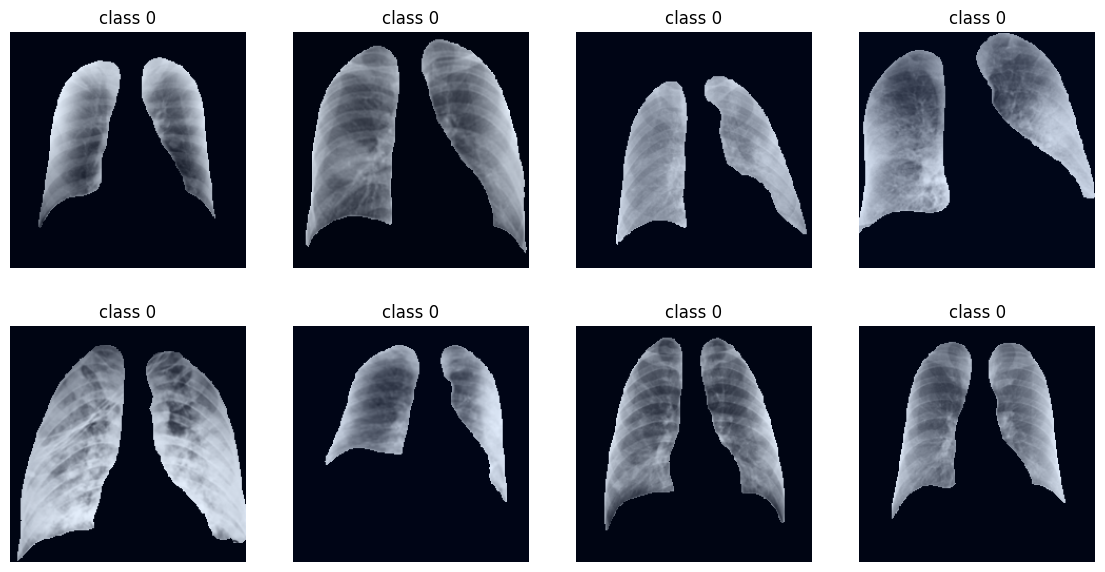

In [13]:
import numpy as np
import matplotlib.pyplot as plt

cfg_check = load_config(REPO_ROOT / 'configs' / 'run2_masked.yaml')
check_ds = build_dataset(manifests['val'].head(8), DATA_ROOT, cfg_check, training=False)
images, labels = next(iter(check_ds))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, image, label in zip(axes.ravel(), images.numpy(), labels.numpy()):
    shown = (image - image.min()) / (np.ptp(image) + 1e-8)
    ax.imshow(shown); ax.set_title(f'class {label.argmax()}'); ax.axis('off')
plt.show()


In [10]:
# 5. One epoch smoke test

from covid_xray.config import RunConfig
from covid_xray.train import set_global_seed

smoke = RunConfig(name='smoke', variant='raw', model='densenet121',
                  stage_a_epochs=1, stage_b_epochs=1, mixed_precision=True)
enable_mixed_precision(smoke)
_, smoke_history = train_two_stage(smoke, *datasets_for(smoke), CKPT_ROOT)
print('smoke val macro-F1:', smoke_history['stage_b']['val_macro_f1'])


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  2/459 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.3672 - loss: 1.4469 - macro_f1: 0.1483   

I0000 00:00:1785484575.720354     196 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6646 - loss: 0.7247 - macro_f1: 0.4905
Epoch 1: val_macro_f1 improved from None to 0.63741, saving model to /kaggle/working/checkpoints/smoke_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/smoke_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 162s 264ms/step - accuracy: 0.7271 - loss: 0.6362 - macro_f1: 0.6967 - val_accuracy: 0.7214 - val_loss: 0.7674 - val_macro_f1: 0.6374
Restoring model weights from the end of the best epoch: 1.
stage B: unfroze 81 layers from 'conv5_block1' (BatchNorm excluded)
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7562 - loss: 0.6075 - macro_f1: 0.5648
Epoch 1: val_macro_f1 improved from None to 0.68905, saving model to /kaggle/working/checkpoints/smoke_stageb.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/smoke_stageb.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 146s 229ms/step - accuracy: 0.7916 - loss: 0.4944 - macro_f1: 0.7659 - val_accuracy: 0.7558 -

In [11]:
!rm -f /kaggle/working/checkpoints/smoke_*
!ls -la /kaggle/working/checkpoints


total 8
drwxr-xr-x 2 root root 4096 Jul 31 08:03 .
drwxr-xr-x 5 root root 4096 Jul 31 07:35 ..


In [14]:
# 6.

model1, history1 = run_densenet('run1_raw')
print('run1 best val macro-F1:', max(history1['stage_b']['val_macro_f1']))


Epoch 1/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6670 - loss: 0.7329 - macro_f1: 0.4875
Epoch 1: val_macro_f1 improved from None to 0.68079, saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 134s 227ms/step - accuracy: 0.7257 - loss: 0.6474 - macro_f1: 0.6922 - val_accuracy: 0.7418 - val_loss: 0.6864 - val_macro_f1: 0.6808
Epoch 2/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7749 - loss: 0.5459 - macro_f1: 0.5809
Epoch 2: val_macro_f1 did not improve from 0.68079
459/459 ━━━━━━━━━━━━━━━━━━━━ 59s 127ms/step - accuracy: 0.7958 - loss: 0.4840 - macro_f1: 0.7742 - val_accuracy: 0.7440 - val_loss: 0.6920 - val_macro_f1: 0.6787
Epoch 3/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7840 - loss: 0.5369 - macro_f1: 0.5858
Epoch 3: val_macro_f1 improved from 0.68079 to 0.69740, saving model to /kaggle/working/checkpoints/ru

In [16]:
# 7. 

model2, history2 = run_densenet('run2_masked')
print('run2 best val macro-F1:', max(history2['stage_b']['val_macro_f1']))


Epoch 1/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6249 - loss: 0.8246 - macro_f1: 0.4614
Epoch 1: val_macro_f1 improved from None to 0.54196, saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 121s 207ms/step - accuracy: 0.7007 - loss: 0.7203 - macro_f1: 0.6519 - val_accuracy: 0.6533 - val_loss: 0.8890 - val_macro_f1: 0.5420
Epoch 2/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7149 - loss: 0.6640 - macro_f1: 0.5380
Epoch 2: val_macro_f1 improved from 0.54196 to 0.54884, saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.7677 - loss: 0.5495 - macro_f1: 0.7341 - val_accuracy: 0.6390 - val_loss: 0.9055 - val_macro_f1: 0.5488
Epoch 3/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0

In [17]:
# 8 .

model4, history4 = run_densenet('run4_lungs_removed')
print('run4 best val macro-F1:', max(history4['stage_b']['val_macro_f1']))


Epoch 1/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6259 - loss: 0.7958 - macro_f1: 0.4535
Epoch 1: val_macro_f1 improved from None to 0.55529, saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 154s 259ms/step - accuracy: 0.6667 - loss: 0.7386 - macro_f1: 0.6329 - val_accuracy: 0.6711 - val_loss: 0.8414 - val_macro_f1: 0.5553
Epoch 2/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7125 - loss: 0.6530 - macro_f1: 0.5366
Epoch 2: val_macro_f1 improved from 0.55529 to 0.59371, saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - accuracy: 0.7464 - loss: 0.5674 - macro_f1: 0.7283 - val_accuracy: 0.6944 - val_loss: 0.7818 - val_macro_f1: 0.5937
Epoch 3/8
45

In [18]:
# 9. The 8x8 liner probe(~2min)

import joblib
from sklearn.metrics import f1_score
from covid_xray.data import extract_downsampled_features
from covid_xray.models import build_probe

X_train, y_train = extract_downsampled_features(manifests['train'], DATA_ROOT, size=8)
X_val,   y_val   = extract_downsampled_features(manifests['val'],   DATA_ROOT, size=8)

probe = build_probe(seed=42).fit(X_train, y_train)
print('probe val macro-F1:', f1_score(y_val, probe.predict(X_val), average='macro'))

# joblib is pickle-based and executes code on load. Safe here: written and read
# only by this project. Never load a .joblib you did not produce yourself.
joblib.dump(probe, CKPT_ROOT / 'run3_probe8.joblib')


probe val macro-F1: 0.6466608991564624


['/kaggle/working/checkpoints/run3_probe8.joblib']

In [19]:
# 10. Verify and persist

import json, glob
for path in sorted(glob.glob(str(CKPT_ROOT / '*_history.json'))):
    payload = json.load(open(path))
    best = max(payload['history']['stage_b']['val_macro_f1'])
    print(f"{payload['config']['name']:22s} best val macro-F1 = {best:.4f}")
!ls -la {CKPT_ROOT}


run1_raw               best val macro-F1 = 0.8568
run2_masked            best val macro-F1 = 0.7519
run4_lungs_removed     best val macro-F1 = 0.8269
total 461572
drwxr-xr-x 2 root root     4096 Jul 31 09:51 .
drwxr-xr-x 5 root root     4096 Jul 31 07:35 ..
-rw-r--r-- 1 root root 63881368 Jul 31 08:30 run1_raw_final.keras
-rw-r--r-- 1 root root     4666 Jul 31 08:30 run1_raw_history.json
-rw-r--r-- 1 root root     1002 Jul 31 08:14 run1_raw_stagea.csv
-rw-r--r-- 1 root root 29757106 Jul 31 08:11 run1_raw_stagea.keras
-rw-r--r-- 1 root root     1821 Jul 31 08:30 run1_raw_stageb.csv
-rw-r--r-- 1 root root 63881368 Jul 31 08:29 run1_raw_stageb.keras
-rw-r--r-- 1 root root 63881371 Jul 31 09:23 run2_masked_final.keras
-rw-r--r-- 1 root root     4670 Jul 31 09:23 run2_masked_history.json
-rw-r--r-- 1 root root      999 Jul 31 09:06 run2_masked_stagea.csv
-rw-r--r-- 1 root root 29757109 Jul 31 09:05 run2_masked_stagea.keras
-rw-r--r-- 1 root root     1822 Jul 31 09:23 run2_masked_stageb.csv
